<a href="https://colab.research.google.com/github/Wendell9/N1_IA/blob/main/Analise_de_Vinhos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

N1 - Inteligência Artificial

Regressão Linear

Nomes:

Igor Albuquerque Pierote 081230041
Paulo Henrique 082220016
Guilherme Augusto Morais da Silva 082220018
Eliza Eduarda 082220039
Wendell Moreira Guindani 082220017

*Orientações:*

Esse arquivo contem o modelo esperado de respostas para a N1. Podem ser acrescentadas algumas outras informações ou trechos com códigos, entretanto não esqueçam de responder todos os pontos que foram levantados a seguir

## Exercício 1

1. Carregar os dataset do exercício:

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Substitua este URL pelo link "raw" do seu arquivo CSV no GitHub
github_csv_url_white_wine = 'https://raw.githubusercontent.com/Wendell9/N1_IA/refs/heads/main/winequality-white.csv'

# Substitua este URL pelo link "raw" do seu arquivo CSV no GitHub
github_csv_url_red_wine = 'https://raw.githubusercontent.com/Wendell9/N1_IA/refs/heads/main/winequality-red.csv'

# Carrega o dataset diretamente do GitHub para um DataFrame do pandas
df_redWine = pd.read_csv(github_csv_url_red_wine,sep = ";")
df_whiteWine = pd.read_csv(github_csv_url_white_wine,sep = ";")

2. Fazer a análise exploratória dos dados

In [2]:
df_redWine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [3]:
df_whiteWine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [4]:
df_whiteWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [5]:
df_redWine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Como pode-se observar, o número de linhas da base de vinhos tintos é maior do que a de vinhos brancos. Considerando o maior número de dados para treinar o modelo e levando em consideração que as expectativas que um enólogo tem a respeito do sabor de um vinho tinto são diferentes do sabor de um vinho branco(o vinho tinto é descrito como um vinho mais encorpado, seco e complexo, como notas de frutas vermelehas; enquanto o vinho branco é considerado mais leve, fresco e ácido, destacando-se pelas suas frutas cítricas), optou-se por utilizar apenas a base de vinhos brancos.

In [6]:
df_whiteWine.duplicated().sum()

np.int64(937)

Os itens considerados 'duplicados' tratam-se de vinhos com os mesmos valores de variáveis e entendo que não necessariamente são duplicados, mas serão dropados justamente pela duplicação de valores que nao serão de valia para o treinamento do modelo, uma vez que podem gerar overfitting e peso desproporcional para determinados padrões.

In [7]:
df_whiteWine.drop_duplicates(inplace=True)
df_whiteWine.shape

(3961, 12)

In [8]:
corr_matrix=df_whiteWine.corr()
corr_matrix['quality'].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.462869
pH,0.123829
sulphates,0.053200
free sulfur dioxide,0.010507
citric acid,0.007065
residual sugar,-0.117339
fixed acidity,-0.124636
total sulfur dioxide,-0.183356
volatile acidity,-0.190678


Detaca-se que os elementos que possuem maior correlação com a qualidade do vinho são o alcool e a densidade.

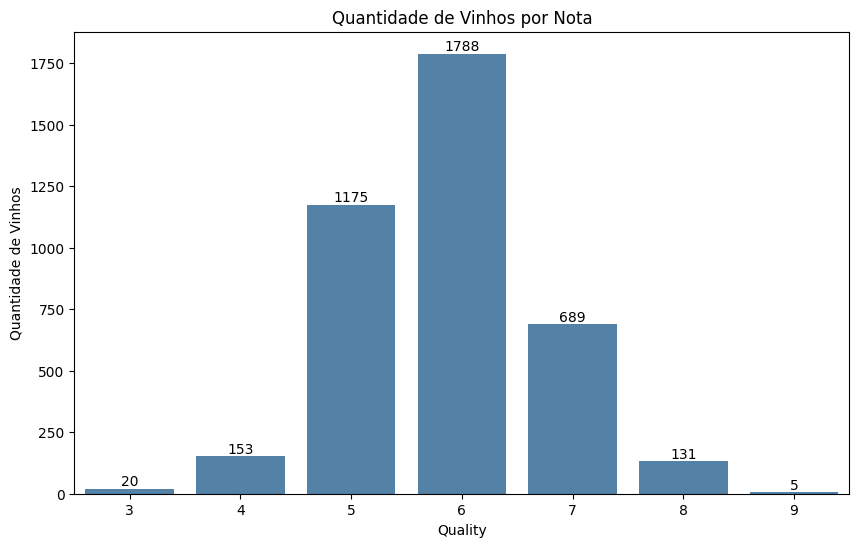

In [9]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_whiteWine, x='quality', color='steelblue')
ax.bar_label(ax.containers[0])  # Adiciona a contagem acima de cada barra

plt.title('Quantidade de Vinhos por Nota')
plt.xlabel('Quality')
plt.ylabel('Quantidade de Vinhos')
plt.show()

Evidencia-se que as notas são majoritariamente de vinhos medianos(notas 5 e 6), e que as notas de qualidade não contemplam todos os vinhos. Ademais, as extremidades das amostras apresentam uma quantidade bem reduzida da amostra(25 no total). Sendo 3 a menor nota e 9 a maior.

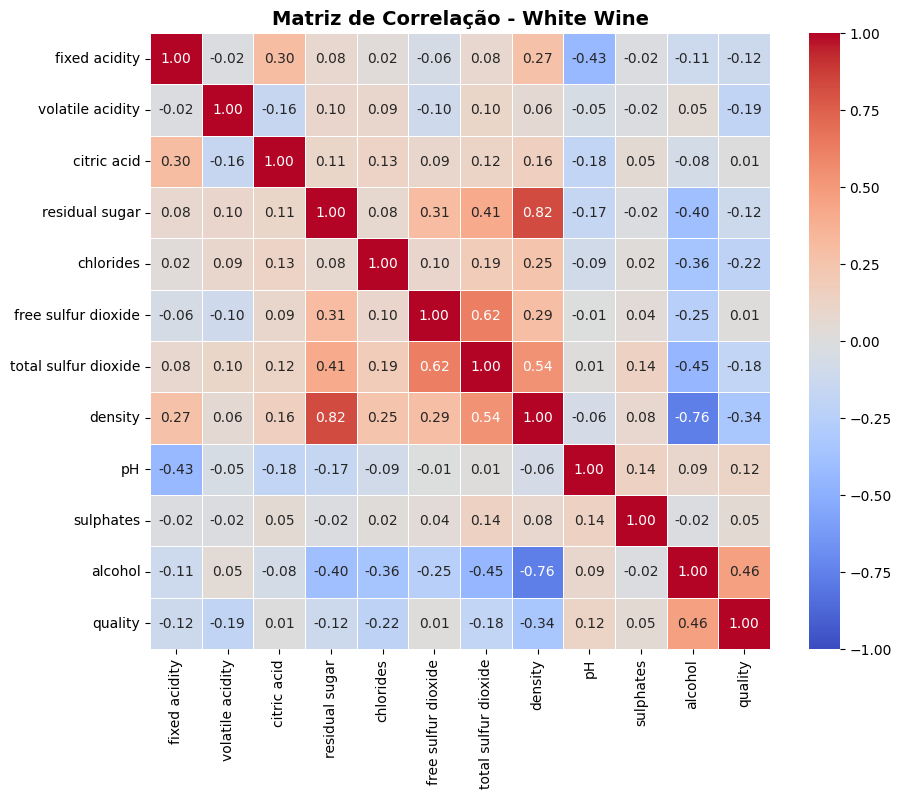

In [10]:
# 1. Calcula a matriz de correlação (apenas para colunas numéricas)
matriz_corr = df_whiteWine.corr(numeric_only=True)

# 2. Define o tamanho da figura
plt.figure(figsize=(10, 8))

# 3. Gera o mapa de calor
sns.heatmap(
    matriz_corr,
    annot=True,         # Exibe o valor numérico em cada quadrado
    fmt='.2f',          # Limita para 2 casas decimais
    cmap='coolwarm',     # Paleta de cores (azul = negativo, vermelho = positivo)
    vmin=-1, vmax=1,    # Define os limites da escala de correlação (-1 a +1)
    linewidths=0.5      # Espaçamento entre as células
)

plt.title('Matriz de Correlação - White Wine', fontsize=14, fontweight='bold')
plt.show()

In [11]:
df_whiteWine['residual sugar/alcohol'] = df_whiteWine['residual sugar'] / df_whiteWine['alcohol']
df_whiteWine['residual sugar/fixed acidity'] = df_whiteWine['residual sugar'] / df_whiteWine['fixed acidity']
df_whiteWine['fixed acidity/alcohol'] = df_whiteWine['fixed acidity']/df_whiteWine['alcohol']
df_whiteWine['citric acid/alcohol'] = df_whiteWine['citric acid']/df_whiteWine['alcohol']
df_whiteWine['citric acid/residual sugar'] = df_whiteWine['citric acid']/df_whiteWine['alcohol']

In [12]:
df_whiteWine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,residual sugar/alcohol,residual sugar/fixed acidity,fixed acidity/alcohol,citric acid/alcohol,citric acid/residual sugar
count,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000,3961.000000
mean,6.839346,0.280538,0.334332,5.914819,0.045905,34.889169,137.193512,0.993790,3.195458,0.490351,10.589358,5.854835,0.587617,0.869013,0.655110,0.032087,0.032087
std,0.866860,0.103437,0.122446,4.861646,0.023103,17.210021,43.129065,0.002905,0.151546,0.113523,1.217076,0.890683,0.516597,0.708057,0.114944,0.012978,0.012978
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.056604,0.068966,0.304688,0.000000,0.000000
25%,6.300000,0.210000,0.270000,1.600000,0.035000,23.000000,106.000000,0.991620,3.090000,0.410000,9.500000,5.000000,0.150794,0.242857,0.571429,0.024490,0.024490
50%,6.800000,0.260000,0.320000,4.700000,0.042000,33.000000,133.000000,0.993500,3.180000,0.480000,10.400000,6.000000,0.423077,0.703125,0.652632,0.029464,0.029464
75%,7.300000,0.330000,0.390000,8.900000,0.050000,45.000000,166.000000,0.995710,3.290000,0.550000,11.400000,6.000000,0.875000,1.285714,0.727273,0.037113,0.037113
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000,5.623932,8.435897,1.279279,0.136066,0.136066


/tmp/ipykernel_748/3032598640.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_whiteWine, x="quality", y=var, ax=ax, palette="Blues")
/tmp/ipykernel_748/3032598640.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_whiteWine, x="quality", y=var, ax=ax, palette="Blues")
/tmp/ipykernel_748/3032598640.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_whiteWine, x="quality", y=var, ax=ax, palette="Blues")
/tmp/ipykernel_748/3032598640.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated

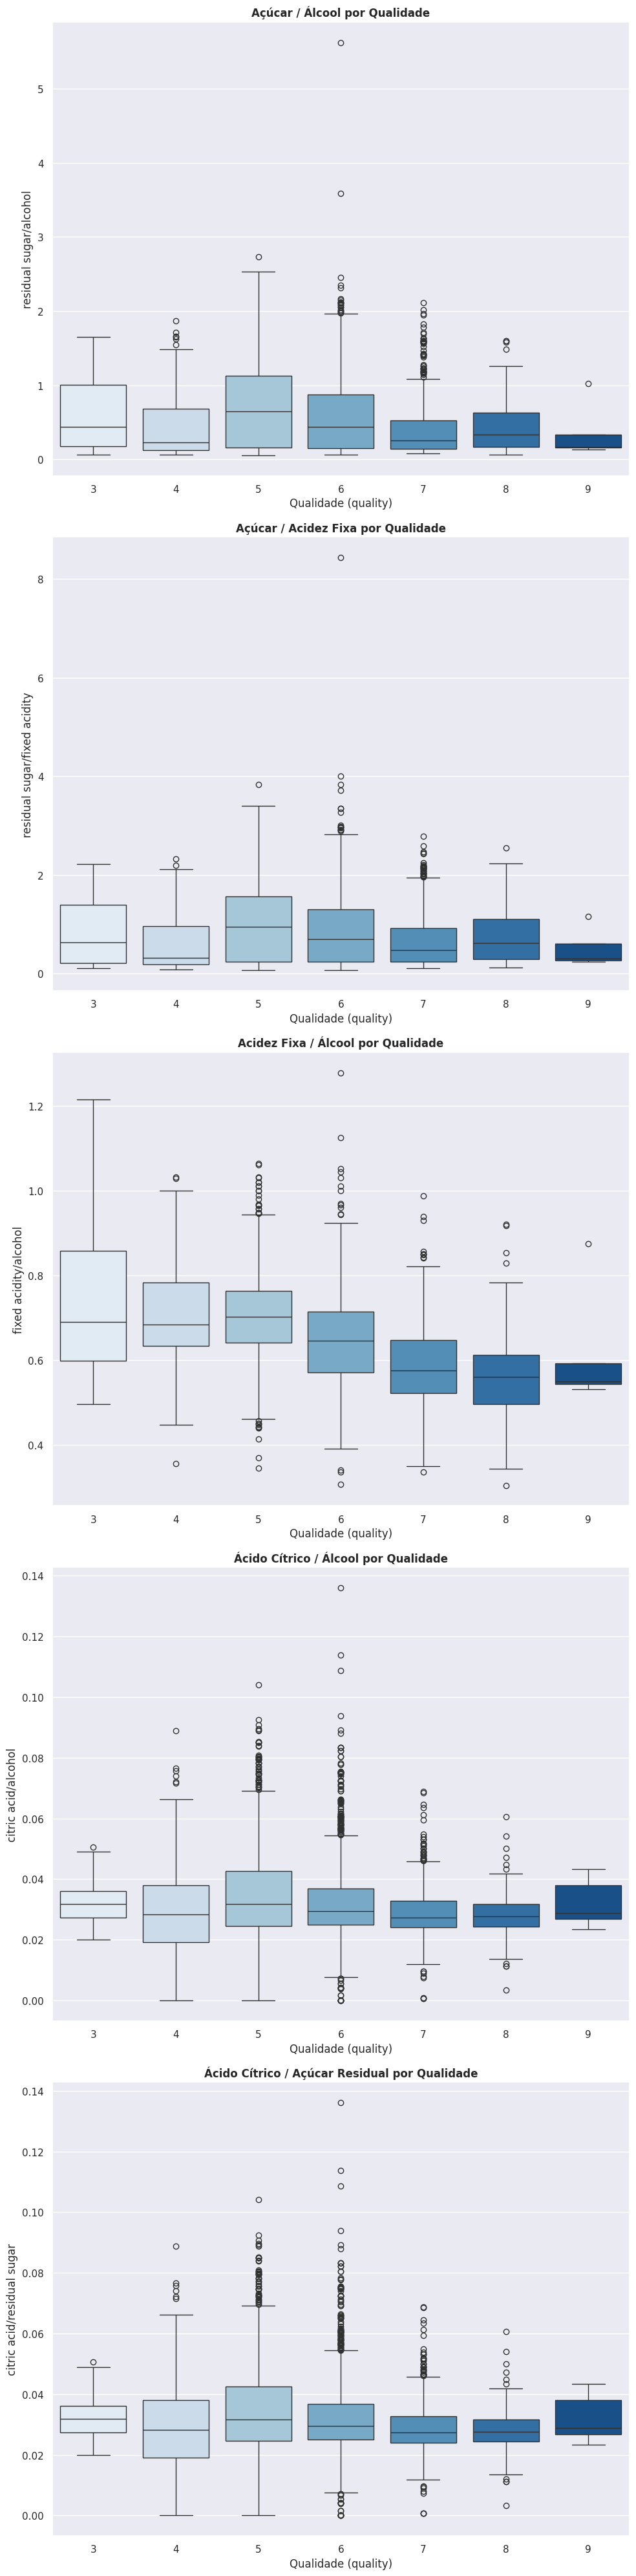

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# Lista das novas variáveis
variaveis = [
    "residual sugar/alcohol",
    "residual sugar/fixed acidity",
    "fixed acidity/alcohol",
    "citric acid/alcohol",
    "citric acid/residual sugar",
]

titulos = [
    "Açúcar / Álcool",
    "Açúcar / Acidez Fixa",
    "Acidez Fixa / Álcool",
    "Ácido Cítrico / Álcool",
    "Ácido Cítrico / Açúcar Residual",
]

# 5 linhas, 1 coluna. Aumentamos a altura (20) para dar espaço adequado a cada subgráfico
fig, axes = plt.subplots(5, 1, figsize=(10, 40))

for ax, var, titulo in zip(axes, variaveis, titulos):
    sns.boxplot(data=df_whiteWine, x="quality", y=var, ax=ax, palette="Blues")
    ax.set_title(f"{titulo} por Qualidade", fontsize=12, fontweight="bold")
    ax.set_xlabel("Qualidade (quality)")
    ax.set_ylabel(var)

plt.tight_layout()  # Ajusta automaticamente o espaçamento entre os subgráficos
plt.show()

In [14]:
corr_matrix=df_whiteWine.corr()
corr_matrix['quality'].sort_values(ascending=False)

,quality
quality,1.000000
alcohol,0.462869
pH,0.123829
sulphates,0.053200
free sulfur dioxide,0.010507
citric acid,0.007065
residual sugar/fixed acidity,-0.105322
residual sugar,-0.117339
citric acid/residual sugar,-0.118121
citric acid/alcohol,-0.118121


OBRIGATÓRIO: Explicar quais features estão envolvidas e o seu respectivo target

As features são alcohol, pH, sulphates, free sulfur dioxide, citric acid, residual sugar/fixed acidity, residual sugar, citric acid/alcohol, fixed acidity, residual sugar/alcohol, total sulfur dioxide, volatile acidity, chlorides, density, dixed acidity/alcohol. Por sua vez a variável target é quality.

In [15]:
X = df_whiteWine.drop(columns=['quality'])
y = df_whiteWine['quality']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42,stratify=y
)

# Decision Tree

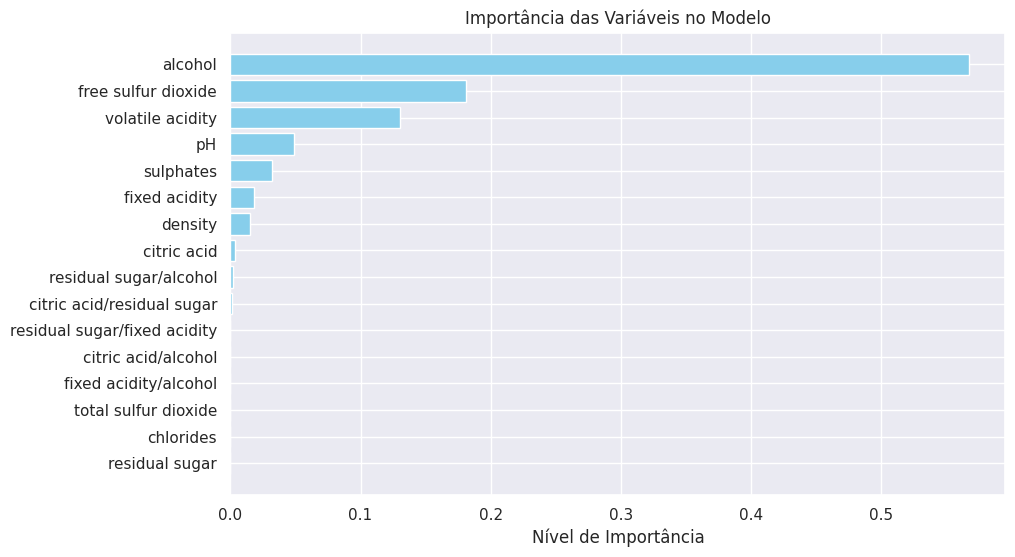

In [17]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

model_dtr = DecisionTreeRegressor(random_state=42, max_depth=5)
scores = cross_val_score(
    model_dtr, X_train, y_train, cv=5, scoring='r2'
)
model_dtr.fit(X_train, y_train)

y_pred_dtr = model_dtr.predict(X_test)

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_dtr.feature_importances_
})


importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

# Random Forest

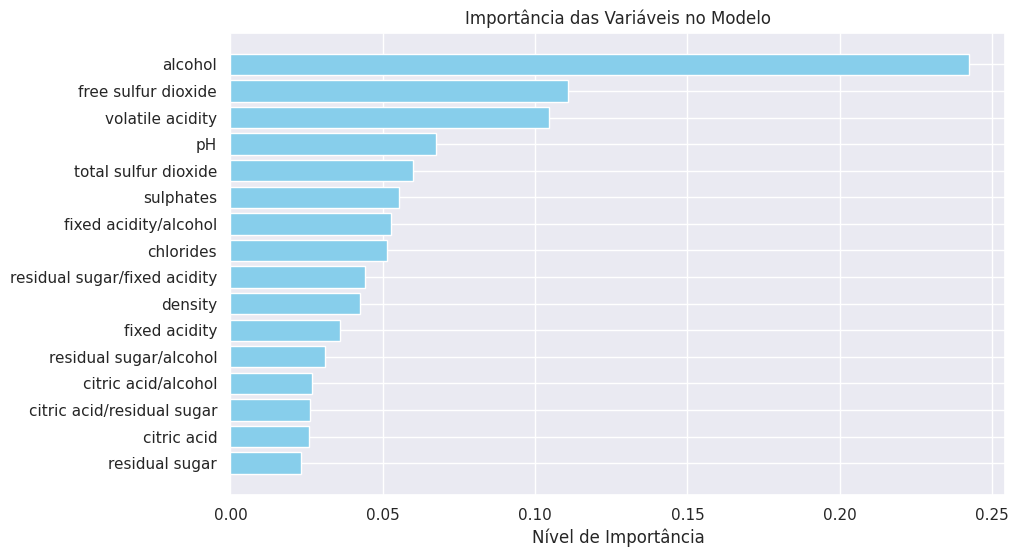

In [18]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100,
                                  random_state=42)
scores = cross_val_score(
    model_rf, X_train, y_train, cv=5, scoring='r2'
)
model_rf.fit(X_train, y_train)


y_pred_rf = model_rf.predict(X_test)

importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_rf.feature_importances_
})


importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

# XGBRegressor

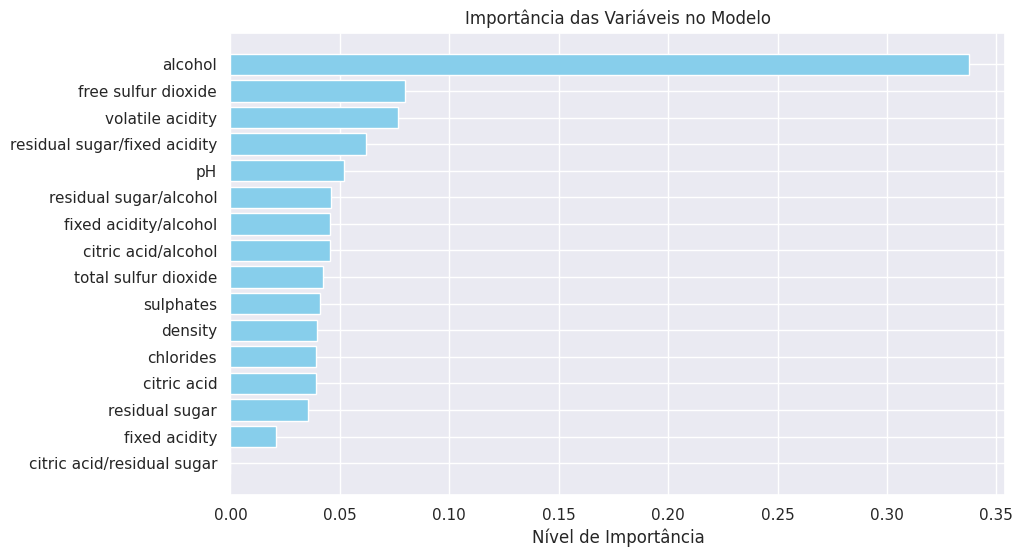

In [19]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

scores = cross_val_score(
    model_xgb, X_train, y_train, cv=5, scoring='r2'
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

# 3. Extraia a importância e crie um DataFrame para visualizar
importancias = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': model_xgb.feature_importances_
})

# 4. Ordene da maior para a menor importância
importancias = importancias.sort_values(by='Importancia', ascending=True)

# 5. Plote um gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias['Variavel'], importancias['Importancia'], color='skyblue')
plt.title('Importância das Variáveis no Modelo')
plt.xlabel('Nível de Importância')
plt.show()

#Ajustando hiperparametros dos modelos

### Ajuste de Hiperparâmetros para Árvore de Decisão

Para a Árvore de Decisão, podemos ajustar `max_depth` (profundidade máxima da árvore) para controlar o overfitting, `min_samples_split` (número mínimo de amostras para dividir um nó) e `min_samples_leaf` (número mínimo de amostras em uma folha).

Melhores hiperparâmetros para Decision Tree: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


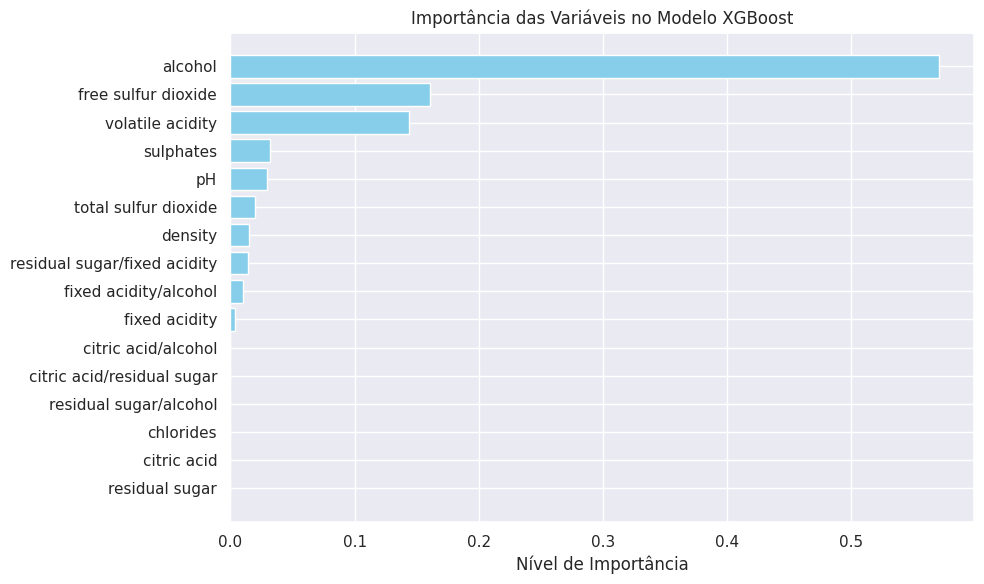

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Define o grid de parâmetros para Decision Tree Regressor
param_grid_dtr = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

model_dtr_tuned_grid = DecisionTreeRegressor(random_state=42)
grid_search_dtr = GridSearchCV(estimator=model_dtr_tuned_grid, param_grid=param_grid_dtr, cv=5, scoring='r2', n_jobs=-1)
grid_search_dtr.fit(X_train, y_train)

print(f"Melhores hiperparâmetros para Decision Tree: {grid_search_dtr.best_params_}")

model_dtr_tuned = grid_search_dtr.best_estimator_
scores_dtr_tuned = cross_val_score(model_dtr_tuned, X_train, y_train, cv=5, scoring='r2')
y_pred_dtr_tuned = model_dtr_tuned.predict(X_test)

# 3. Extrai a importância usando o modelo treinado
importancias = pd.DataFrame(
    {"Variavel": X.columns, "Importancia": model_dtr_tuned.feature_importances_}
)

# 4. Ordena da maior para a menor importância
importancias = importancias.sort_values(by="Importancia", ascending=True)

# 5. Plota o gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias["Variavel"], importancias["Importancia"], color="skyblue")
plt.title("Importância das Variáveis no Modelo XGBoost")
plt.xlabel("Nível de Importância")
plt.tight_layout()
plt.show()

### Ajuste de Hiperparâmetros para XGBoost Regressor

Para o XGBoost, podemos ajustar `n_estimators` (número de árvores), `learning_rate` (tamanho do passo de cada iteração), `max_depth` (profundidade máxima de cada árvore) e `subsample`.

Melhores hiperparâmetros para XGBoost: {'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 300, 'subsample': 0.7}


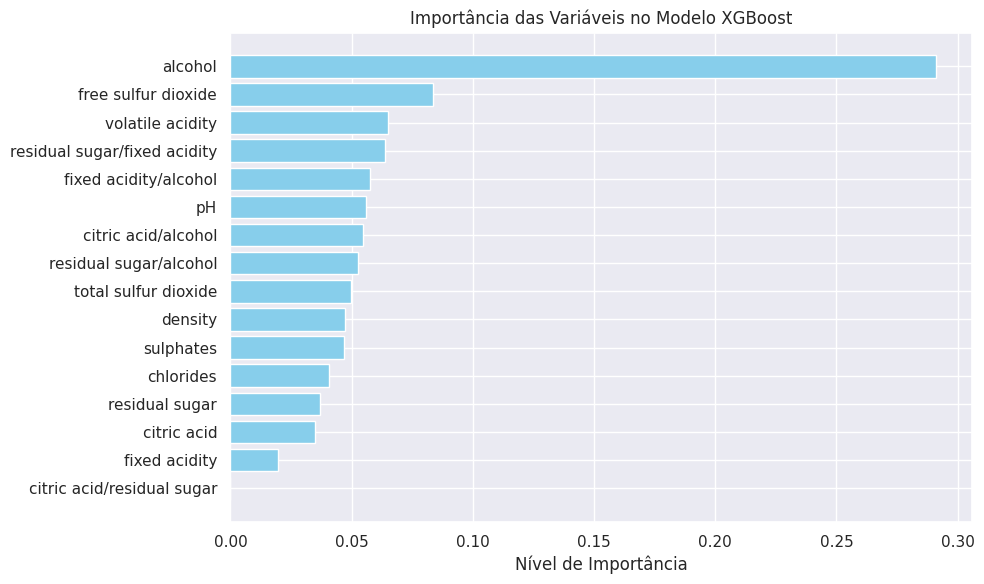

In [21]:
from sklearn.model_selection import GridSearchCV
# 1. Define o grid de parâmetros para XGBoost Regressor
param_grid_xgb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 7, 9],
    "subsample": [0.7, 0.8, 0.9],
}

model_xgb_tuned_grid = XGBRegressor(random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=model_xgb_tuned_grid,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_search_xgb.fit(X_train, y_train)

print(f"Melhores hiperparâmetros para XGBoost: {grid_search_xgb.best_params_}")

# 2. Pega o melhor modelo treinado
model_xgb_tuned = grid_search_xgb.best_estimator_
y_pred_xgb_tuned = model_xgb_tuned.predict(X_test)

# 3. Extrai a importância usando o modelo treinado
importancias = pd.DataFrame(
    {"Variavel": X.columns, "Importancia": model_xgb_tuned.feature_importances_}
)

# 4. Ordena da maior para a menor importância
importancias = importancias.sort_values(by="Importancia", ascending=True)

# 5. Plota o gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias["Variavel"], importancias["Importancia"], color="skyblue")
plt.title("Importância das Variáveis no Modelo XGBoost")
plt.xlabel("Nível de Importância")
plt.tight_layout()
plt.show()

#Melhores hiperparâmetros para XGBoost: {'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 300, 'subsample': 0.7}
#Melhor R² médio no CV: 0.3685

#Melhores hiperparâmetros para XGBoost: {'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 300, 'subsample': 0.7}

### Ajuste de Hiperparâmetros para Random Forest

Para Random Forest, podemos ajustar `n_estimators` (número de árvores na floresta), `max_depth` (profundidade máxima de cada árvore) e `min_samples_leaf`.

Melhores hiperparâmetros para Random Forest: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 300}


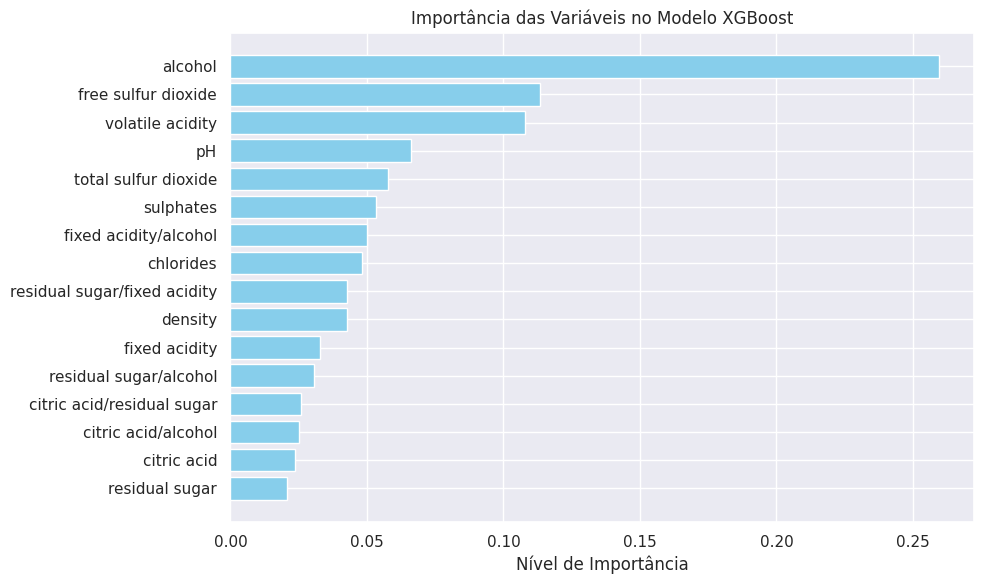

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define o grid de parâmetros para Random Forest Regressor
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [1, 2, 4]
}

model_rf_tuned_grid = RandomForestRegressor(random_state=42)
grid_search_rf = GridSearchCV(estimator=model_rf_tuned_grid, param_grid=param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print(f"Melhores hiperparâmetros para Random Forest: {grid_search_rf.best_params_}")

model_rf_tuned = grid_search_rf.best_estimator_
scores_rf_tuned = cross_val_score(model_rf_tuned, X_train, y_train, cv=5, scoring='r2')
y_pred_rf_tuned = model_rf_tuned.predict(X_test)

# 3. Extrai a importância usando o modelo treinado
importancias = pd.DataFrame(
    {"Variavel": X.columns, "Importancia": model_rf_tuned.feature_importances_}
)

# 4. Ordena da maior para a menor importância
importancias = importancias.sort_values(by="Importancia", ascending=True)

# 5. Plota o gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(importancias["Variavel"], importancias["Importancia"], color="skyblue")
plt.title("Importância das Variáveis no Modelo XGBoost")
plt.xlabel("Nível de Importância")
plt.tight_layout()
plt.show()

##4. Metricas de desempenho

(Usar as métricas de desempenho para comparar os resultados)

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def print_metrics(y_true, y_pred, model_name=""):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    print(f"{model_name}:")
    print(f"  MSE = {mse:.4f}")
    print(f"  MAE = {mae:.4f}")
    print(f"  R²  = {r2:.4f}")
    print("-"*30)

# Métricas para cada modelo
print_metrics(y_test, y_pred_dtr, "DecisionTreeRegressor")
print_metrics(y_test, y_pred_rf,  "RandomForestRegressor")
print_metrics(y_test, y_pred_xgb, "XGBRegressor")

DecisionTreeRegressor:
  MSE = 0.6073
  MAE = 0.6011
  R²  = 0.2343
------------------------------
RandomForestRegressor:
  MSE = 0.4945
  MAE = 0.5442
  R²  = 0.3766
------------------------------
XGBRegressor:
  MSE = 0.5070
  MAE = 0.5579
  R²  = 0.3609
------------------------------


### 4.1 Métricas de Desempenho dos Modelos ajustados
Agora vamos comparar as métricas de desempenho dos modelos após o ajuste de hiperparâmetros.

In [24]:
print_metrics(y_test, y_pred_dtr_tuned, "DecisionTreeRegressor (Tuned)")
print_metrics(y_test, y_pred_rf_tuned,  "RandomForestRegressor (Tuned)")
print_metrics(y_test, y_pred_xgb_tuned, "XGBRegressor (Tuned)")

DecisionTreeRegressor (Tuned):
  MSE = 0.6208
  MAE = 0.6084
  R²  = 0.2174
------------------------------
RandomForestRegressor (Tuned):
  MSE = 0.4887
  MAE = 0.5435
  R²  = 0.3840
------------------------------
XGBRegressor (Tuned):
  MSE = 0.4847
  MAE = 0.5435
  R²  = 0.3890
------------------------------


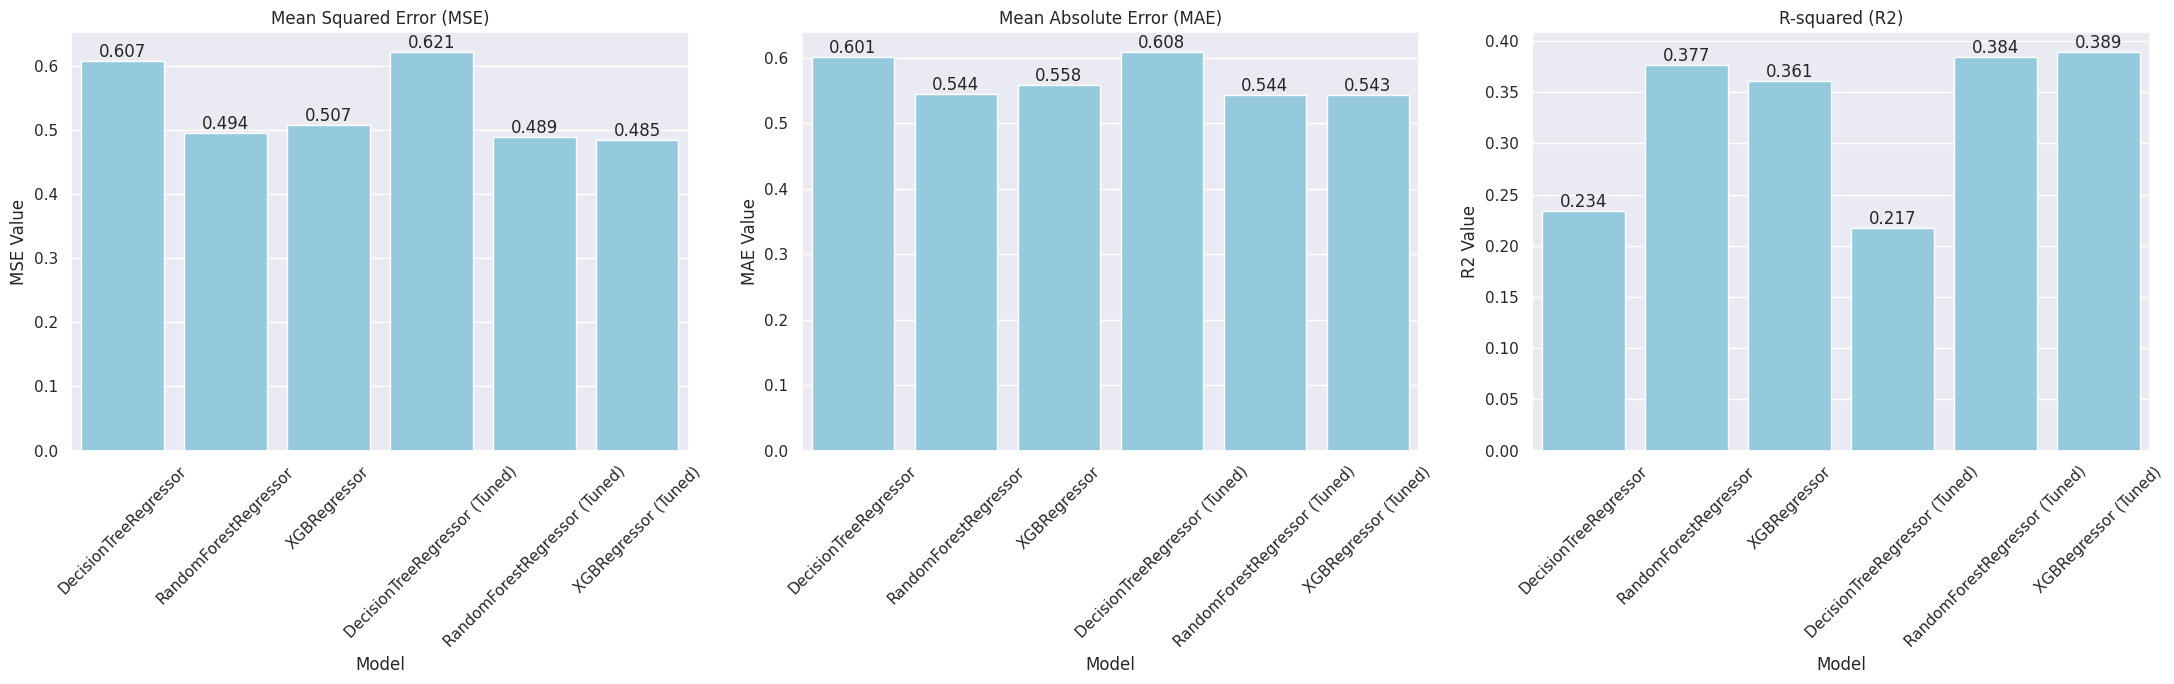

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a dictionary to store the metrics for both original and tuned models
metrics_data = {
    'Model': [
        'DecisionTreeRegressor',
        'RandomForestRegressor',
        'XGBRegressor',
        'DecisionTreeRegressor (Tuned)',
        'RandomForestRegressor (Tuned)',
        'XGBRegressor (Tuned)'
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_dtr),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xgb),
        mean_squared_error(y_test, y_pred_dtr_tuned),
        mean_squared_error(y_test, y_pred_rf_tuned),
        mean_squared_error(y_test, y_pred_xgb_tuned)
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_dtr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_dtr_tuned),
        mean_absolute_error(y_test, y_pred_rf_tuned),
        mean_absolute_error(y_test, y_pred_xgb_tuned)
    ],
    'R2': [
        r2_score(y_test, y_pred_dtr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_dtr_tuned),
        r2_score(y_test, y_pred_rf_tuned),
        r2_score(y_test, y_pred_xgb_tuned)
    ]
}

df_metrics = pd.DataFrame(metrics_data)

# Plotting the metrics
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# MSE Plot
sns.barplot(x='Model', y='MSE', data=df_metrics, ax=axes[0], color='skyblue')
axes[0].set_title('Mean Squared Error (MSE)')
axes[0].set_ylabel('MSE Value')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f')

# MAE Plot
sns.barplot(x='Model', y='MAE', data=df_metrics, ax=axes[1], color='skyblue')
axes[1].set_title('Mean Absolute Error (MAE)')
axes[1].set_ylabel('MAE Value')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f')

# R2 Plot
sns.barplot(x='Model', y='R2', data=df_metrics, ax=axes[2], color='skyblue')
axes[2].set_title('R-squared (R2)')
axes[2].set_ylabel('R2 Value')
axes[2].set_xlabel('Model')
axes[2].tick_params(axis='x', rotation=45)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

##5.Conclusões

Com base nas métricas de desempenho avaliadas, o **XGBRegressor (Tuned)** apresentou o melhor desempenho com um R² de **0.3890**, seguido pelo RandomForestRegressor (Tuned) com R² de 0.3840. O DecisionTreeRegressor (Tuned) obteve o menor R². Isso indica que, após o ajuste de hiperparâmetros, o XGBoost é o modelo mais adequado para prever a qualidade do vinho branco neste conjunto de dados. Além disso, cabe notar que em termos de erro tanto o RandomForestRegressor(Tuned) quanto o XGBRegressor(Tuned) apresentam o mesmo valor de Erro Absoluto Médio e Erro Quadrado Médio.
Apesar do XGBRegressor (Tuned) ter apresentado o melhor desemepenho é evidente que o r² está abaixo do que poderia ser considerado aceitável, uma vez que o valor de 0.3890 indica que a partir das features envolvidas o modelo tem pouca capacidade de explicar e prever a variável alvo.
Após avaliação do grupo, concluiu-se que as características químicas oferecidas a respeito dos vinhos brancos não são o suficientes para explicar a nota dada pelos enólogos acerca da qualidade do vinho, que apesar de se tratar de uma avaliação especializada ainda é, em ultima analise, subjetiva.